In [1]:
import pydicom as dicom
import matplotlib.pylab as plt
import pandas as pd
import os
import numpy as np
import cv2
from skimage.transform import hough_line, hough_line_peaks, probabilistic_hough_line
from skimage.feature import canny
from skimage.draw import line as draw_line
from skimage import data
from matplotlib import cm
import matplotlib.patches as mpatches
from scipy.ndimage import zoom
from skimage import exposure, filters, feature


In [3]:
# vamos começar por fazer o image_path
excel = pd.read_csv('metadata\\metadata.csv')
n = 0
# image_path = {}
# ficheiro = {}
full_path = {}
for line in excel.index:
        image_path = os.path.join('D:\\', 'teste',
                                        'cbis_ddsm',
                                        excel.loc[line, excel.columns[0]],
                                        excel.loc[line, excel.columns[1]],
                                        excel.loc[line, excel.columns[2]])
        ficheiro = os.listdir(os.path.join(image_path))[0]
        full_path[n] = os.path.join(image_path, ficheiro)
        n += 1

# df = pd.DataFrame(list(full_path.items()), columns=["full_path", "patient_id", "left_or_right_breast","breast_density", "image_view", "assessment"])
#image_path = 'b39bc242-61d0-46b1-b56d-0bf721f10007.dcm'
# ds = dicom.dcmread(image_path)
# plt.imshow(ds.pixel_array)

In [4]:
database_com_tudo = pd.read_csv('D:\\DAC2\\calc_case_description_train_set.csv')
# data = {}
# for i in full_path:
#         idx = database[database["image file path"].str.contains(full_path[i], na=False, regex=False)].index[0] 
#         data[i] = [full_path[i], database.loc[idx, "patient_id"], database.loc[idx, "left or right breast"], database.loc[idx, "breast density"], database.loc[idx, "image view"], database.loc[idx, "assessment"]]
        
# df = pd.DataFrame(data, columns=["full_path", "patient_id", "left_or_right_breast","breast_density", "image_view", "assessment"])

data = {}
for i in full_path:
    normalised_full = full_path[i].replace("\\", "/")
    normalised_full = "/".join(normalised_full.split("/")[-4:-1])  # Get the last four parts of the path (e.g., "patient_id/image_file.dcm")

    
    matches = database_com_tudo[database_com_tudo["image file path"].apply(
        lambda x: normalised_full in str(x).replace("\\", "/")
    )]
    
    if len(matches) == 0:
        print(f"No match found for: {normalised_full}")
        continue
    
    idx = matches.index[0]
    data[i] = [full_path[i], database_com_tudo.loc[idx, "patient_id"], database_com_tudo.loc[idx, "left or right breast"], database_com_tudo.loc[idx, "image view"], database_com_tudo.loc[idx, "breast density"], database_com_tudo.loc[idx, "assessment"]]

#df é a base de dados q vamos usar!!
df = pd.DataFrame.from_dict(data, orient='index', columns=["full_path", "patient_id", "left_or_right_breast","image_view", "breast_density", "assessment"])
#ordenar df pelo patient_id?


Já temos a base de dados como deve ser, no df

In [11]:
# Vamos começar por uma só imagem
path = "D:\\teste\\cbis_ddsm\\Calc-Training_P_00060_RIGHT_MLO\\1.3.6.1.4.1.9590.100.1.2.91476110713172979911552183463315793043\\1.3.6.1.4.1.9590.100.1.2.81224121613615658336040014641017971693\\8ca1e479-e723-40f1-a7cd-c80d40620f67.dcm"
ds = dicom.dcmread(path)
# plt.imshow(ds.pixel_array)

In [12]:
# Aqui é para tirar os números que aparecem na imagem for some reason
def tirar_num(pixel_array):
    img = pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min())
    img_uint8 = (img * 255).astype(np.uint8)

    # Threshold para separar fundo do resto
    _, mask = cv2.threshold(img_uint8, 10, 255, cv2.THRESH_BINARY)

    # Manter só o maior componente conectado (a mama) — remove tudo o resto incluindo números
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    clean_mask = (labels == largest).astype(np.uint8) * 255

    result = cv2.bitwise_and(img_uint8, img_uint8, mask=clean_mask)
    return result

In [13]:
# Aplicar a função (neste caso só a uma imagem, depois vai ser a todas)
result = tirar_num(ds.pixel_array)

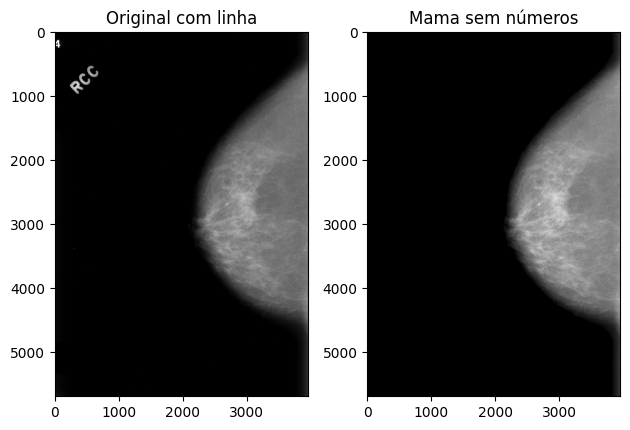

In [ ]:
# Dar plot à imagem original e à imagem sem os números
# plt.subplot(1, 2, 1)
# plt.imshow(ds.pixel_array, cmap="gray")
# plt.title("Original com linha")
# plt.tight_layout()

# plt.subplot(1, 2, 2)
# plt.imshow(result, cmap="gray")
# plt.title("Mama sem números")
# plt.tight_layout()
# plt.show()

In [ ]:
#vamos fazer o pré processamento dos artigos
#feito com a ajuda do Claude
def preprocess(ds):
    """
    Load a DICOM mammogram and apply the three preprocessing steps from the paper:
      1. Log-normalisation → optical density (histogram equalisation)
      2. Downsample 4x via bicubic interpolation
      3. Flip right-side images so the chest wall is always on the LEFT edge
    """
    raw = ds.pixel_array.astype(np.float32) # convert to float for processing

    # 1st - log-normalisation to approximate optical density
    # usado para features com uma grande variância - aplica um logaritmo, o que vai evidenciar detalhes em zonas mais escuras
    raw = np.clip(raw, 1, None)                     # avoid log(0)
    log_img = np.log(raw) # log-normalisation
    od = (log_img - log_img.min()) / (log_img.max() - log_img.min() + 1e-8) # histogram equalisation to [0, 1]

    # 2nd - downsampling
    #the original image pixel-resolution is
    print(ds.PixelSpacing)
    small = zoom(od, 0.25, order=3)                 # order=3 → bicubic

    # --- Step 3: flip right MLO views so chest wall is on the left ---
    # DICOM tag ImageLaterality or laterality from the filename
    laterality = ""
    if hasattr(ds, "ImageLaterality"):
        laterality = ds.ImageLaterality.strip().upper()
    elif hasattr(ds, "Laterality"):
        laterality = ds.Laterality.strip().upper()

    if laterality == "R":
        small = np.fliplr(small)

    return small.astype(np.float32)




In [15]:
# 1. Preprocess
img = preprocess(result)


# 3. Compute breast density (% dense tissue — placeholder, needs your dense-tissue classifier)
# breast_pixels = mask.sum()
# dense_pixels = ...  (from your dense-tissue step)
# density = dense_pixels / breast_pixels * 100

# 4. Quick visual check
fig = plt.figure(figsize=(14, 5))
plt.imshow(img, cmap="gray")
plt.title("Preprocessed")
plt.show()
# axes[1].imshow(mask,        cmap="gray"); axes[1].set_title("Breast mask")
# axes[2].imshow(img,         cmap="gray"); axes[2].set_title("Pectoral boundary")

# if pec_line:
#     _, _, x0, y0, x1, y1 = pec_line
#     axes[2].plot([x0, x1], [y0, y1], "r-", lw=2, label="Pectoral line")
#     axes[2].legend()

# plt.tight_layout()
# plt.savefig("segmentation_result.png", dpi=150)
# plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices